In [28]:
# Import libraries
import pandas as pd
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv('Cancer_Data.csv')

# Drop 'id' column (lowercase)
df.drop('id', axis=1, inplace=True)

# Separate features and target
X = df.drop('diagnosis', axis=1)  # 'diagnosis' column is also lowercase
y = df['diagnosis']

# Display basic info
print("Dataset shape:", df.shape)
print("Class distribution:\n", y.value_counts())
df.head()


Dataset shape: (569, 32)
Class distribution:
 diagnosis
B    357
M    212
Name: count, dtype: int64


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [29]:
# Perform train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

# Combine X and y for manipulation
train_data = X_train.copy()
train_data['Diagnosis'] = y_train

test_data = X_test.copy()
test_data['Diagnosis'] = y_test

# Extract rows with Diagnosis = 'M' from training data
m_rows = train_data[train_data['Diagnosis'] == 'M']

# Randomly sample 120 rows of 'M' from train data
m_rows_sampled = m_rows.sample(n=120, random_state=42)

# Remove these sampled rows from train data
train_data = train_data.drop(m_rows_sampled.index)

# Append these 120 rows to test data
test_data = pd.concat([test_data, m_rows_sampled])

# Separate features and target again
X_train = train_data.drop('Diagnosis', axis=1)
y_train = train_data['Diagnosis']

X_test = test_data.drop('Diagnosis', axis=1)
y_test = test_data['Diagnosis']

# Check new class distribution
print("Training class distribution:\n", y_train.value_counts())
print("Testing class distribution:\n", y_test.value_counts())



Training class distribution:
 Diagnosis
B    285
M     50
Name: count, dtype: int64
Testing class distribution:
 Diagnosis
M    162
B     72
Name: count, dtype: int64


In [30]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np

# Store models and feature importances
trees = []
feature_importances = []

# Loop for 10 trees
for i in range(10):
    # Sample bagging: Resample X_train, y_train with replacement
    X_sampled, y_sampled = resample(X_train, y_train, replace=True, random_state=42+i)
    
    # Decision Tree with feature bagging (sqrt)
    tree = DecisionTreeClassifier(max_features='sqrt', class_weight='balanced', random_state=42+i)
    tree.fit(X_sampled, y_sampled)
    
    # Store the trained tree and its feature importance
    trees.append(tree)
    feature_importances.append(tree.feature_importances_)

print("10 Decision Trees Trained Successfully.")


10 Decision Trees Trained Successfully.


In [31]:
# Convert list of importances to numpy array
feature_importances = np.array(feature_importances)

# Average feature importances across all trees
avg_importances = np.mean(feature_importances, axis=0)

# Create DataFrame to display feature importances
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': avg_importances
}).sort_values(by='Importance', ascending=False)

# Show top 10 important features
print(feature_importance_df.head(10))


                 Feature  Importance
7    concave points_mean    0.173830
23            area_worst    0.165380
20          radius_worst    0.111076
27  concave points_worst    0.102439
22       perimeter_worst    0.098863
26       concavity_worst    0.082353
2         perimeter_mean    0.064269
3              area_mean    0.061014
21         texture_worst    0.019093
6         concavity_mean    0.017565


In [32]:
# Select top 10 features
top_features = feature_importance_df['Feature'].head(10).tolist()

print("Selected Top Features:\n", top_features)


Selected Top Features:
 ['concave points_mean', 'area_worst', 'radius_worst', 'concave points_worst', 'perimeter_worst', 'concavity_worst', 'perimeter_mean', 'area_mean', 'texture_worst', 'concavity_mean']


In [33]:
# Subset training data with shortlisted features
X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]

# Store new models (trees trained on shortlisted features)
trees_selected = []

for i in range(10):
    # Sample bagging: Resample with replacement
    X_sampled, y_sampled = resample(X_train_selected, y_train, replace=True, random_state=42+i)
    
    # Decision Tree with feature bagging (sqrt)
    tree = DecisionTreeClassifier(max_features='sqrt', class_weight='balanced', random_state=42+i)
    tree.fit(X_sampled, y_sampled)
    
    # Store the tree
    trees_selected.append(tree)

print("10 Decision Trees retrained on shortlisted features.")


10 Decision Trees retrained on shortlisted features.


In [36]:
def get_tree_predictions(trees, X):
    preds = []
    for tree in trees:
        preds.append(tree.predict(X))
    preds = np.array(preds).T  # shape (samples, 10)
    
    # Encode predictions: B -> 0, M -> 1
    preds_encoded = (preds == 'M').astype(int)
    return preds_encoded



In [37]:
tree_preds_train = get_tree_predictions(trees_selected, X_train_selected)
X_train_combined = np.hstack((X_train_selected.values, tree_preds_train))



In [39]:
# Logistic Regression
log_reg.fit(X_train_combined, y_train_encoded)
master_tree = DecisionTreeClassifier(class_weight='balanced', random_state=42)
master_tree.fit(X_train_combined, y_train_encoded)

# Master Decision Tree
master_tree.fit(X_train_combined, y_train_encoded)


DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [40]:
from sklearn.metrics import accuracy_score, recall_score

# Get tree predictions for test data
tree_preds_test = get_tree_predictions(trees_selected, X_test_selected)

# Combine shortlisted features + tree predictions
X_test_combined = np.hstack((X_test_selected.values, tree_preds_test))

# Predict using Logistic Regression
log_reg_preds = log_reg.predict(X_test_combined)

# Predict using Master Decision Tree
master_tree_preds = master_tree.predict(X_test_combined)

# Evaluate Logistic Regression
log_reg_acc = accuracy_score(y_test_encoded, log_reg_preds)
log_reg_recall = recall_score(y_test_encoded, log_reg_preds)

# Evaluate Master Decision Tree
master_tree_acc = accuracy_score(y_test_encoded, master_tree_preds)
master_tree_recall = recall_score(y_test_encoded, master_tree_preds)

print("Logistic Regression - Accuracy:", log_reg_acc, "Recall (M):", log_reg_recall)
print("Master Decision Tree - Accuracy:", master_tree_acc, "Recall (M):", master_tree_recall)


Logistic Regression - Accuracy: 0.9273504273504274 Recall (M): 0.8950617283950617
Master Decision Tree - Accuracy: 0.8547008547008547 Recall (M): 0.7962962962962963


In [41]:
# Evaluate 10 individual trees
tree_accuracies = []
tree_recalls = []

for tree in trees_selected:
    preds = tree.predict(X_test_selected)
    preds_encoded = (preds == 'M').astype(int)
    
    acc = accuracy_score(y_test_encoded, preds_encoded)
    rec = recall_score(y_test_encoded, preds_encoded)
    
    tree_accuracies.append(acc)
    tree_recalls.append(rec)

print("Average Tree Accuracy:", np.mean(tree_accuracies))
print("Average Tree Recall (M):", np.mean(tree_recalls))


Average Tree Accuracy: 0.852991452991453
Average Tree Recall (M): 0.7901234567901235


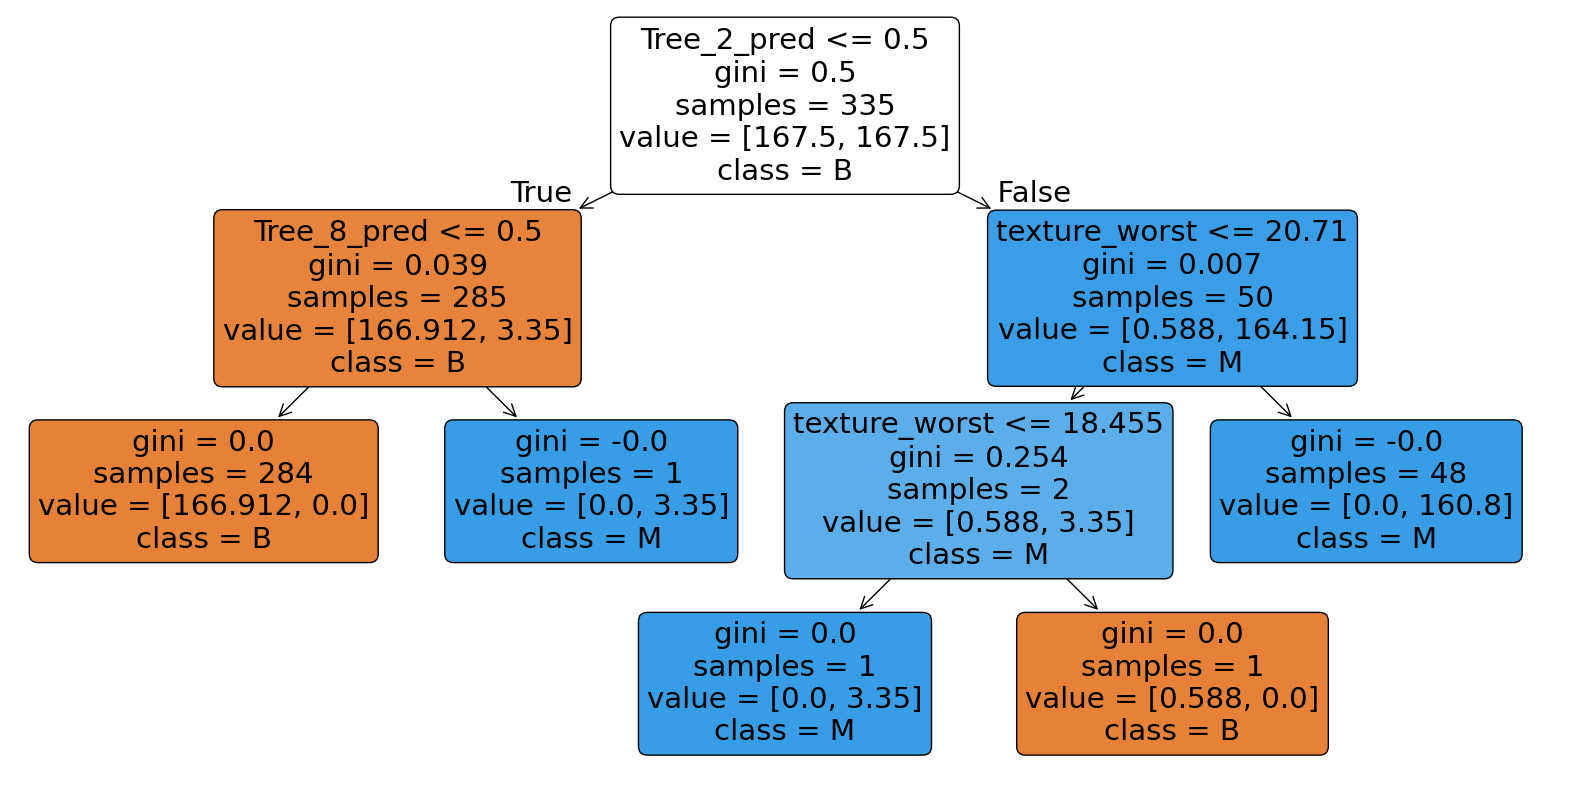

In [42]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Plot the Master Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(master_tree, feature_names=(top_features + [f'Tree_{i+1}_pred' for i in range(10)]),
          class_names=['B', 'M'], filled=True, rounded=True)
plt.show()
